<a href="https://colab.research.google.com/github/Pedroct06/Curso-LLM-From-Scratch/blob/main/PipelineCompleto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Pedroct06/Curso-LLM-From-Scratch.git

fatal: destination path 'Curso-LLM-From-Scratch' already exists and is not an empty directory.


Fazendo os imports das funções feitas anteriormente

In [2]:
import os
import requests
import torch
import tiktoken
import matplotlib.pyplot as plt
import sys

sys.path.append('/content/Curso-LLM-From-Scratch')

from Aulas_anteriores import(
    GPTDatasetV1,
    create_dataloader_v1,
    MultiHeadAttention,
    LayerNorm,
    GELU,
    FeedForward,
    TransformerBlock,
    GPTModel,
    generate_text_simple,
)

torch.manual_seed(123)

Pegando o texto da internet, e utilizando o tiktoken para tokenizar o texto

In [3]:
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
)

file_path = "the-verdict.txt"

if not os.path.exists(file_path):
  response = requests.get(url, timeout=300)
  response.raise_for_status()
  with open(file_path, "w", encoding = "utf-8") as f:
    f.write(response.text)

with open(file_path, "r", encoding = "utf-8") as f:
  text_data = f.read()

print("Caracteres: ", len(text_data))
print(text_data[:200])


Caracteres:  20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a


In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = tokenizer.encode(
    text_data,
    allowed_special= {"<|endoftext|>"}
)

print("Quantidade de tokens: ", len(token_ids))
print("Primeiros tokens", token_ids[:20])


Quantidade de tokens:  5145
Primeiros tokens [40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438]


Treino e validação

In [5]:
GPT_CONFIG = {
    "vocab_size": tokenizer.n_vocab,
    "context_length": 128,
    "emb_dim": 128,
    "n_layers": 4,
    "n_heads": 4,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))

train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

train_loader = create_dataloader_v1(
    train_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=4,
    max_length=GPT_CONFIG["context_length"],
    stride=GPT_CONFIG["context_length"],
    shuffle=False,
    drop_last=True,
    num_workers=0,
)

print("Batches de treino:", len(train_loader))
print("Batches de validacao:", len(val_loader))

x, y = next(iter(train_loader))
print("Entrada: ", x.shape)
print("Saida: ", y.shape)

Batches de treino: 9
Batches de validacao: 1
Entrada:  torch.Size([4, 128])
Saida:  torch.Size([4, 128])


Utilizando a Multi-Head attention

In [6]:
torch.manual_seed(123)

attention = MultiHeadAttention(
    d_in=GPT_CONFIG["emb_dim"],
    d_out=GPT_CONFIG["emb_dim"],
    context_length=GPT_CONFIG["context_length"],
    dropout=GPT_CONFIG["drop_rate"],
    num_heads=GPT_CONFIG["n_heads"],
    qkv_bias=GPT_CONFIG["qkv_bias"],
)

dummy = torch.rand(2,16, GPT_CONFIG["emb_dim"])

attention_output = attention(dummy)

print("Entrada: ", dummy.shape)
print("Saida: ", attention_output.shape)

Entrada:  torch.Size([2, 16, 128])
Saida:  torch.Size([2, 16, 128])


Utilizando o transformer e a config do GTP

In [7]:
model = GPTModel(GPT_CONFIG)

num_parameters = sum(p.numel() for p in model.parameters())

print(model,
      "\n")
print(f"Quantidade de parametros: , {num_parameters:,}")

GPTModel(
  (tok_emb): Embedding(50257, 128)
  (pos_emb): Embedding(128, 128)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=128, out_features=128, bias=False)
        (W_key): Linear(in_features=128, out_features=128, bias=False)
        (W_value): Linear(in_features=128, out_features=128, bias=False)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU()
          (2): Linear(in_features=512, out_features=128, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1

Testando o forward pass

In [8]:
input_batch, target_batch = next(iter(train_loader))

with torch.no_grad():
  logits = model(input_batch)

print("Input: ", input_batch.shape)
print("Logits: ", logits.shape)

Input:  torch.Size([4, 128])
Logits:  torch.Size([4, 128, 50257])


Calculando a Loss

In [9]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)

  logits = model(input_batch)

  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0,1),
      target_batch.flatten()
  )
  return loss


def calc_loss_loader(data_loader, model, device, num_batches = None):
  if len(data_loader) == 0:
    return float("nan")

  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  total_loss= 0.0
  model.eval()

  with torch.no_grad():
    for i, (input_batch, target_batch) in enumerate(data_loader):
      if i >= num_batches: break
      total_loss += calc_loss_batch(
          input_batch,
          target_batch,
          model,
          device
      ).item()

  model.train()

  return total_loss/ num_batches

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = model.to(device)

print("Dispositivo:", device)

with torch.no_grad():
    train_loss_before = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss_before = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )

print(f"Loss inicial de treino: {train_loss_before:.4f}")
print(f"Loss inicial de validação: {val_loss_before:.4f}")

Dispositivo: cuda
Loss inicial de treino: 10.9869
Loss inicial de validação: 10.9866


In [11]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter =5):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)

  model.train()
  return train_loss, val_loss


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=10,
    eval_iter=5,
    pacience=3
):
  train_losses = []
  val_losses = []
  tokens_seen = []

  total_tokens = 0
  global_step = -1

  for epoch in range(num_epochs):
    print("Época seguinte")
    model.train()

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()

      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm =1.0)
      optimizer.step()
      total_tokens += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader,device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        tokens_seen.append(total_tokens)

        print(f"Época: {epoch + 1:02d} | ")
        print(f"Step: {global_step:04d} | ")
        print(f"Train Loss: {train_loss:.4f} | ")
        print(f"Val loss: {val_loss:.4f}")
  return train_losses, val_losses, tokens_seen


Hiperparametros e treinamento do modelo

In [12]:
NUM_EPOCHS = 30
LEARNING_RATE = 4e-4
WEIGHT_DECAY = 0.1

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

train_losses, val_losses, tokens_seen = train_model(
    model=model,
    train_loader = train_loader,
    val_loader= val_loader,
    optimizer = optimizer,
    device = device,
    num_epochs= NUM_EPOCHS,
    eval_freq= 9,
    eval_iter= 5,
    pacience =3
)

Época seguinte
Época: 01 | 
Step: 0000 | 
Train Loss: 10.9493 | 
Val loss: 10.9496
Época seguinte
Época: 02 | 
Step: 0009 | 
Train Loss: 10.3437 | 
Val loss: 10.4636
Época seguinte
Época: 03 | 
Step: 0018 | 
Train Loss: 9.5243 | 
Val loss: 9.6950
Época seguinte
Época: 04 | 
Step: 0027 | 
Train Loss: 8.7529 | 
Val loss: 8.9830
Época seguinte
Época: 05 | 
Step: 0036 | 
Train Loss: 8.0410 | 
Val loss: 8.3099
Época seguinte
Época: 06 | 
Step: 0045 | 
Train Loss: 7.4040 | 
Val loss: 7.7198
Época seguinte
Época: 07 | 
Step: 0054 | 
Train Loss: 6.8260 | 
Val loss: 7.2532
Época seguinte
Época: 08 | 
Step: 0063 | 
Train Loss: 6.5118 | 
Val loss: 6.9413
Época seguinte
Época: 09 | 
Step: 0072 | 
Train Loss: 6.2859 | 
Val loss: 6.7655
Época seguinte
Época: 10 | 
Step: 0081 | 
Train Loss: 6.1357 | 
Val loss: 6.6683
Época seguinte
Época: 11 | 
Step: 0090 | 
Train Loss: 6.0556 | 
Val loss: 6.6050
Época seguinte
Época: 12 | 
Step: 0099 | 
Train Loss: 5.9068 | 
Val loss: 6.5665
Época seguinte
Época: 13

Gráfico para verificar o comportamento das losses

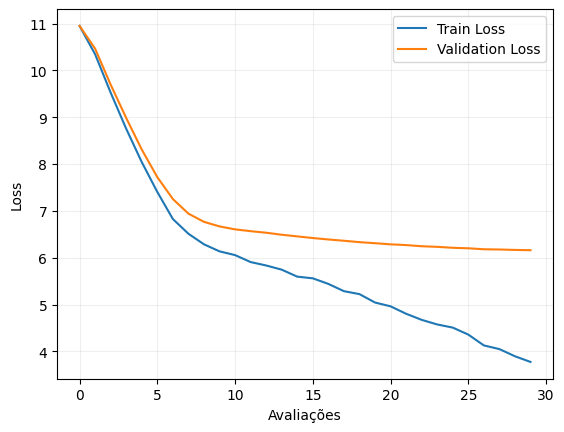

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Avaliações")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Funções para geração de texto

In [14]:
def text_to_tokens_ids(text, tokenizer, device):
  encoded = tokenizer.encode(
      text,
      allowed_special = {"<|endoftext|>"}
  )

  return torch.tensor(
      encoded,
      dtype = torch.long,
      device = device
  ).unsqueeze(0)

def tokens_ids_to_text(token_ids, tokenizer):
  token_ids = token_ids.squeeze(0).tolist()
  return tokenizer.decode(token_ids)

Geração de texto

In [15]:
model.eval()

text = "Every effort moves you"

input_ids = text_to_tokens_ids(
    text,
    tokenizer,
    device
)

generated_ids = generate_text_simple(
    model = model,
    idx = input_ids,
    max_new_tokens = 80,
    context_size = GPT_CONFIG["context_length"]
)

generated_text = tokens_ids_to_text(
    generated_ids, tokenizer
)

print(generated_text)

Every effort moves you, I had been was the--and and--I--and, and in the had been, and, and it, as a to the, as of the Riv to the--I had been, and he was. The--and.


"I., and to the picture of the his own a little of the Riv.

"Oh, and I had been,


Como podemos observar, a geração não foi 100% correta, pois existem alguns problemas como:

*   Dataset muito pequeno
*   Pouco treinamento, pois como o dataset é curto e o modelo tem muitos parâmetros a mais, fica fácil de ter overfitting, então não treinei muito
*   Como o modelo gerou um token errado, ele fica utilizando esse token para gerar o próximo e assim aumenta o erro recursivamente



Salvando o modelo

In [17]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": GPT_CONFIG,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "tokens_seen": tokens_seen,
    "num_epochs": NUM_EPOCHS
}

# Salva o checkpoint
torch.save(checkpoint, "PipelineCompleto.pth")

print("Modelo salvo com sucesso!")
print("Arquivo: PipelineCompleto.pth")

Modelo salvo com sucesso!
Arquivo: PipelineCompleto.pth


In [18]:
from google.colab import files

files.download("PipelineCompleto.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>